In [ ]:
import pandas as pd

df = pd.read_csv('/sample_-_superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Shape of the dataset (rows, columns)
print("Shape:", df.shape)

# Column names and data types
print("\nColumn Info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (9994, 21)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 

In [ ]:
# Convert Order Date and Ship Date to actual datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

# Confirm it worked
print(df[['Order Date', 'Ship Date']].dtypes)

# Descriptive statistics for numerical columns
df.describe()

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


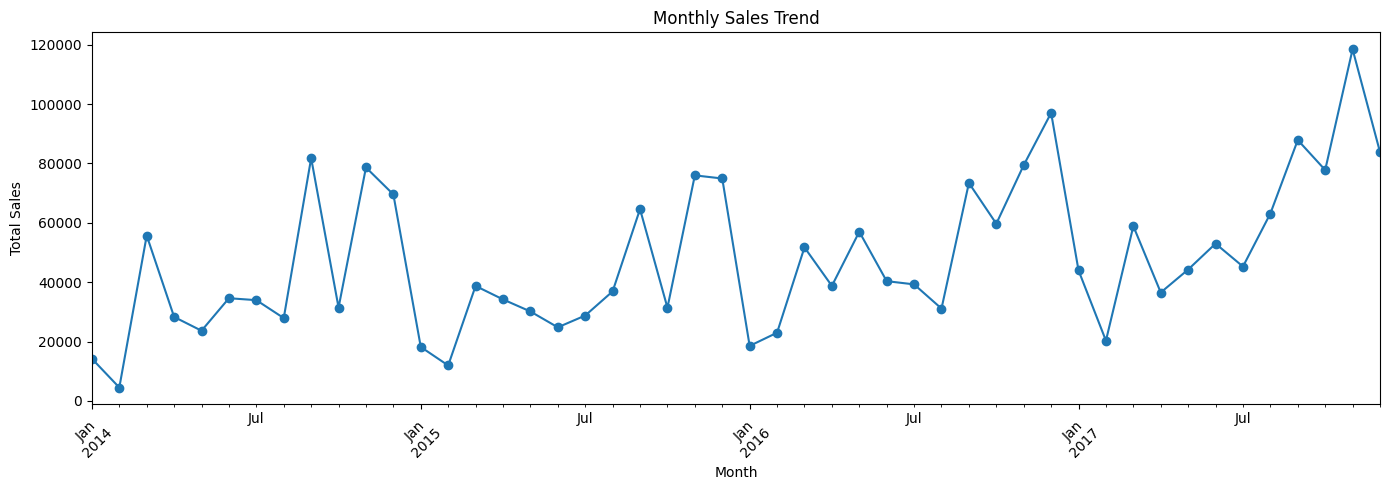

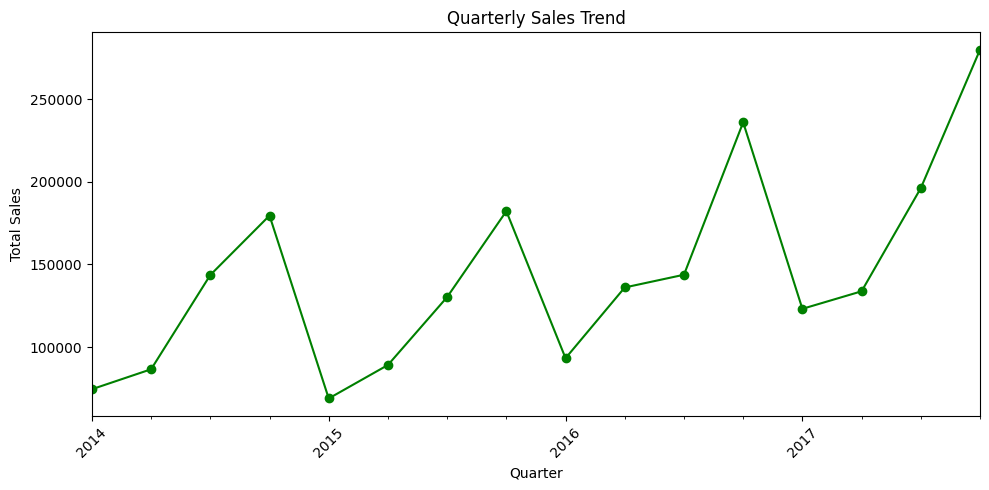

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a date index for time-based grouping
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')

# Monthly sales trend
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quarterly sales trend
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

plt.figure(figsize=(10,5))
quarterly_sales.plot(kind='line', marker='o', color='green')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly & Quarterly Sales Trend
Sales show a general upward trend over the years, with noticeable spikes in November and December each year, likely driven by holiday season shopping (Black Friday, year-end sales).

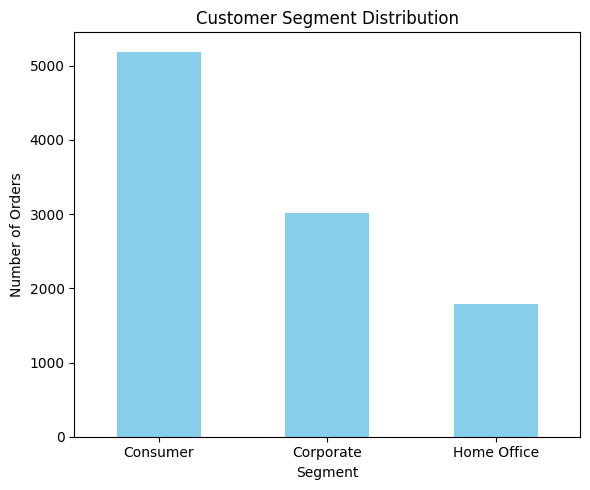

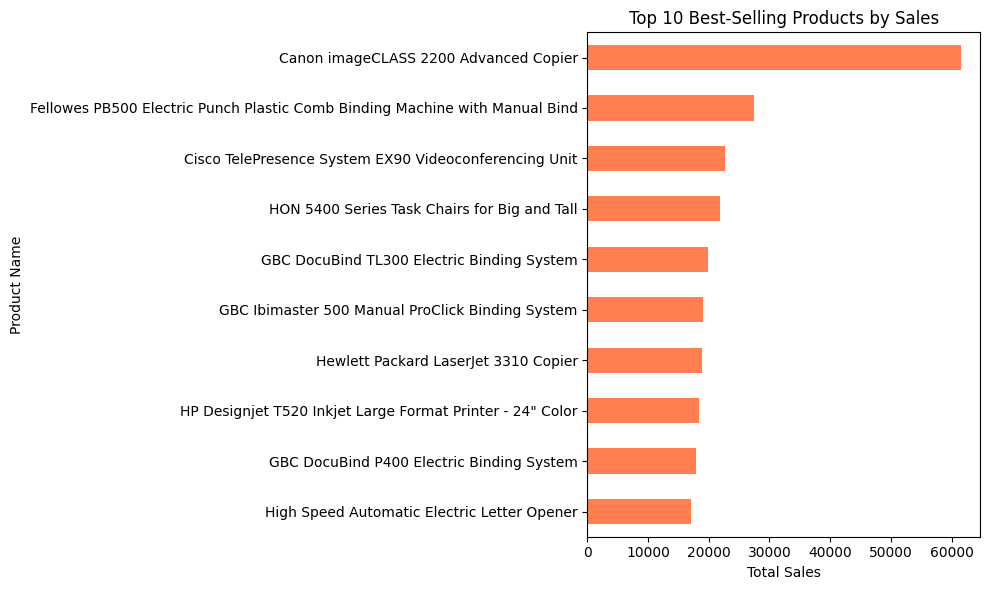

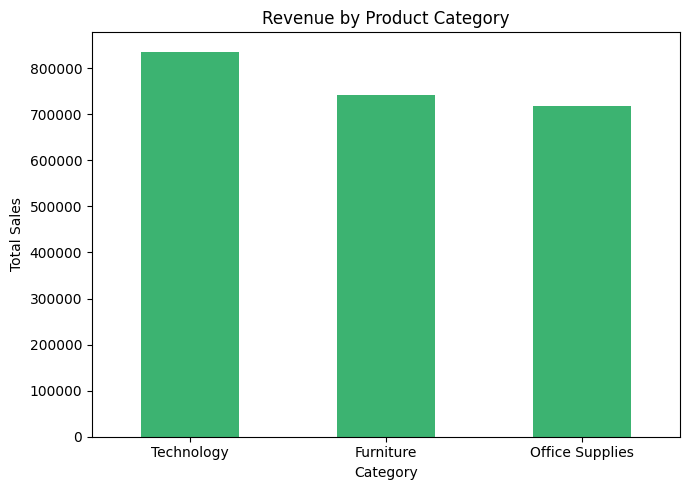

In [11]:
# Customer segment distribution
plt.figure(figsize=(6,5))
df['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Top 10 best-selling products (by total sales)
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='coral')
plt.title('Top 10 Best-Selling Products by Sales')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Revenue by product category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
category_sales.plot(kind='bar', color='mediumseagreen')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Customer Segment Distribution
The Consumer segment places the highest number of orders, followed by Corporate and Home Office. This suggests marketing and inventory should prioritize individual consumer needs.

### Top 10 Best-Selling Products
A small number of products — mostly high-ticket items like copiers, chairs, and phones — drive a disproportionate share of total sales, suggesting these are strategic products worth prioritizing in promotions.

### Revenue by Category
Technology and Furniture generate the highest revenue, while Office Supplies, despite likely higher order volume, contributes less per order.

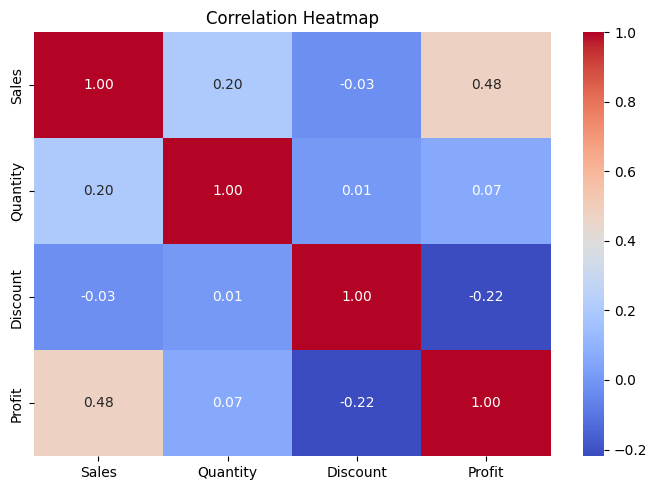

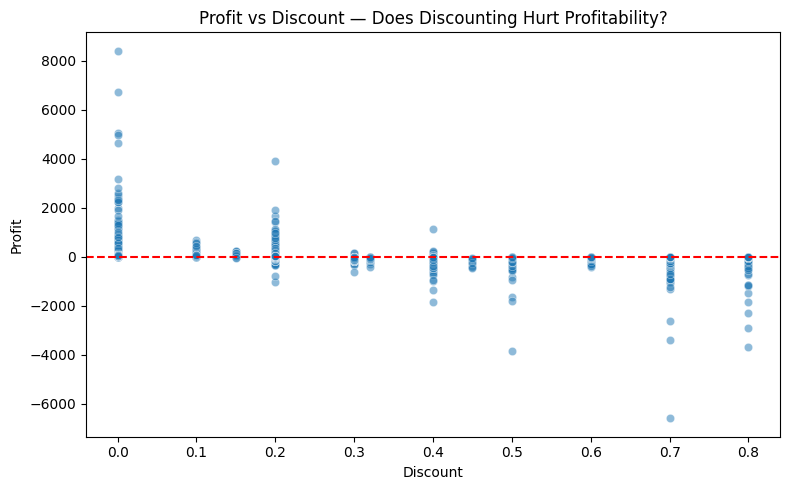

In [12]:
# Correlation heatmap between numerical variables
plt.figure(figsize=(7,5))
numeric_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Extra insightful chart: Profit vs Discount (does high discount hurt profit?)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title('Profit vs Discount — Does Discounting Hurt Profitability?')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### Correlation Heatmap & Discount vs Profit
Discount shows a negative correlation with Profit — as discounts increase, profitability drops sharply, with many high-discount orders resulting in a net loss. This suggests the company should review its discounting strategy, especially for deep discounts above 30-40%.

## Conclusion & Business Recommendations

1. **Review discounting policy above 40%**: Data shows profit turns negative
once discounts exceed ~40%. The company should cap standard discounts at
20-30% unless clearing excess inventory, and require manager approval for
anything higher.

2. **Double down on Technology and Furniture categories**: These generate
the highest revenue. Consider expanding product range or running targeted
promotions in these categories during Q4 (Nov-Dec), when sales already
peak seasonally.

3. **Focus retention efforts on the Consumer segment**: Since Consumers
place the most orders, loyalty programs or personalized offers targeted at
this segment could meaningfully boost repeat purchases.

4. **Investigate high-discount, high-loss products**: A deeper dive into
which specific products are sold at a loss even without heavy discounting
could reveal pricing issues unrelated to discounts.